# Cubo Gelatinoso

### Introdução:
Nessa atividade serão abordadas as etapas fundamentais de Aprendizado de Máquina - vamos selecionar um dataset, tratar os dados, criar um modelo baseado no KNearest-Neighbors e comparar os resultados de diferentes hiperparâmetros. Começaremos importando as seguintes bibliotecas:

In [58]:
import sklearn.tree as sk
import pandas as pd
import seaborn as sns
import numpy as np
import statistics as st

O Dataset selecionado é sobre doença renal crônica, retirado do repositório de machine learning da UCI (link de acesso [1]). Ele possui 25 atributos, sendo 1 deles o target desse projeto, que representa a presença ou ausência de doença renal crônica. A seguir, vamos compreender esses atributos e suas características:

| Atributo | Significado                               | Tipo de dados      | Valores / Unidade                 |
| -------- | ----------------------------------------- | ------------------ | --------------------------------- |
| `age`    | Idade do paciente                         | Numérico           | Anos                              |
| `bp`     | Pressão arterial                          | Numérico           | mm/Hg                             |
| `sg`     | Gravidade específica da urina             | Categórico ordinal | 1.005; 1.010; 1.015; 1.020; 1.025 |
| `al`     | Nível de albumina na urina                | Categórico ordinal | 0–5                               |
| `su`     | Nível de açúcar na urina                  | Categórico ordinal | 0–5                               |
| `rbc`    | Presença de glóbulos vermelhos na urina   | Categórico binário | normal / abnormal                 |
| `pc`     | Presença de células de pus                | Categórico binário | normal / abnormal                 |
| `pcc`    | Presença de aglomerados de células de pus | Categórico binário | present / notpresent              |
| `ba`     | Presença de bactérias                     | Categórico binário | present / notpresent              |
| `bgr`    | Glicose sanguínea aleatória               | Numérico           | mg/dL                             |
| `bu`     | Ureia sanguínea                           | Numérico           | mg/dL                             |
| `sc`     | Creatinina sérica                         | Numérico           | mg/dL                             |
| `sod`    | Concentração de sódio no sangue         | Numérico           | mEq/L                             |
| `pot`    | Concentração de potássio no sangue        | Numérico           | mEq/L                             |
| `hemo`   | Nível de hemoglobina                      | Numérico           | g/dL                              |
| `pcv`    | Volume globular (hematócrito)             | Numérico           | %                                 |
| `wc`     | Contagem de glóbulos brancos              | Numérico           | células/cumm                      |
| `rc`     | Contagem de glóbulos vermelhos            | Numérico           | milhões/cmm                       |
| `htn`    | Presença de hipertensão                   | Categórico binário | yes / no                          |
| `dm`     | Presença de diabetes mellitus             | Categórico binário | yes / no                          |
| `cad`    | Presença de doença arterial coronariana   | Categórico binário | yes / no                          |
| `appet`  | Apetite do paciente                       | Categórico binário | good / poor                       |
| `pe`     | Presença de edema periférico              | Categórico binário | yes / no                          |
| `ane`    | Presença de anemia                        | Categórico binário | yes / no                          |
| `class`  | Diagnóstico de doença renal crônica       | Categórico binário | ckd / notckd                      |

###### Tabela criada e modificada com o auxílio de AI.

Entre os dados, temos 11 numéricos e 14 categóricos. Entre os categóricos, 3 deles são ordinais e 11 são nominais (especificamente binários).

O atributo target será "class", que representa se o indivíduo exemplo do dataset possui ou não doença renal crônica (ckd). Vamos agora acessar o arquivo do dataset e chamar todos os dados "?" de NaN (pois o algoritmo KNN pode identificar dados "?" como dados válidos):

In [59]:
import pandas as pd

dataset = pd.read_csv(
    "chronic_kidney_disease.arff",
    skiprows=29,
    header=None,
    usecols=range(25)
)

dataset = dataset.replace("?", np.nan)
# Dados com valor "?" foram substituídos para NaN, para melhor comunicação com a linguagem Python.

dataset.columns = dataset.columns.astype(str)
# Converte os nomes das colunas de inteiros para strings. Isso será necessário para o OneHotEncoder posteriormente.

dataset

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,48,80,1.020,1,0,NaN,normal,notpresent,notpresent,121,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7,50,1.020,4,0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62,80,1.010,2,3,normal,normal,notpresent,notpresent,423,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51,80,1.010,2,0,normal,normal,notpresent,notpresent,106,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55,80,1.020,0,0,normal,normal,notpresent,notpresent,140,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,42,70,1.025,0,0,normal,normal,notpresent,notpresent,75,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,12,80,1.020,0,0,normal,normal,notpresent,notpresent,100,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,17,60,1.025,0,0,normal,normal,notpresent,notpresent,114,...,51,7200,5.9,no,no,no,good,no,no,notckd


Por enquanto, o Python lê todas as colunas do dataset como categóricas, embora algumas sejam numéricas. Vamos corrigir isso:

In [60]:
dataset = dataset.apply(pd.to_numeric, errors='ignore')

C:\Users\vitor2610039\AppData\Local\Temp\ipykernel_30320\2650093943.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dataset = dataset.apply(pd.to_numeric, errors='ignore')


O FutureWarning acima apareceu por causa da versão do Pandas, mas não é um erro e não represena nenhum problema. Podemos prosseguir normalmente.

Vamos chamar os dados do target de dados_y, e os dados do treino de dados_x:

In [61]:
dados_y = dataset["24"]

dados_x = dataset.drop(columns = ["24"])

Agora, fazemos a divisão entre dados de teste e dados de treino com o Train Test Split. O valor test_size, que regula quantos dados serão separados para o test, será definido de modo que 75% dos dados sejam para treino e 25% para teste.

In [62]:
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(dados_x, dados_y, test_size = 0.25, random_state = 2112)

Perfeito! Nosso dataset foi dividido. Mas temos muitos dados faltantes... então, será realizado um processo de imputação. Esse processo consiste em atribuir um valor para cada dado faltante do dataset. Para atributos categóricos, esse valor será determinado pela moda dos dados. Para atributos numéricos, o valor será  determinado pela mediana dos dados (pois a mediana é menos sensível a dados extremos do que a média).
Primeiro, vamos realizar a imputação nos dados de treino (x_treino) com o método .fit, e depois faremos o mesmo com os dados de teste (x_teste) a partir do método .transform:

In [63]:
from sklearn.impute import SimpleImputer

colunas_cat = x_treino.select_dtypes(include = ["object", "category"]).columns
colunas_num = x_treino.select_dtypes(include = ["int", "float64"]).columns

imputer_cat = SimpleImputer(missing_values = np.nan, strategy = "most_frequent")
imputer_cat.fit(x_treino[colunas_cat])
x_treino[colunas_cat] = imputer_cat.transform(x_treino[colunas_cat])

imputer_num = SimpleImputer(missing_values = np.nan, strategy = "median")
imputer_num.fit(x_treino[colunas_num])
x_treino[colunas_num] = imputer_num.transform(x_treino[colunas_num])
# Até agora realizamos a imputação em x_treino


x_teste[colunas_cat] = imputer_cat.transform(x_teste[colunas_cat])
x_teste[colunas_num] = imputer_num.transform(x_teste[colunas_num])
# Agora fizemos o mesmo para x_teste

Show! Deu certo, e agora nosso dataset não tem nenhum dado faltante. Verificamos isso a partir do código abaixo: o resultado da linha de código deve ser False tanto para x_treino quanto para x_teste:

In [64]:
print(x_treino.isnull().values.any())
print(x_teste.isnull().values.any())

False
False


Mas vamos utilizar um algoritmo KNN, então não podemos manter nenhum dado categórico na forma de string. Por causa disso, iremos usar o One Hot Encoder para atribuir valores numéricos aos atributos categóricos.

Ponto importante: ao utilizarmos o One Hot Encoder, novas colunas serão criadas em x_treino e x_teste. Isso será levado em consideração quando aplicarmos os hiperparâmetros no futuro.

In [65]:
from sklearn.preprocessing import OneHotEncoder

colunas_cat = x_treino.select_dtypes(include = ["object", "category"]).columns
colunas_num = x_treino.select_dtypes(include = ["int", "float64"]).columns
# Definindo as colunas categóricas e as colunas numéricas

encoder = OneHotEncoder(sparse_output = False, handle_unknown="ignore")

treino_cat_df = pd.DataFrame(
    encoder.fit_transform(x_treino[colunas_cat]),
    # .fit_transform realiza fit e transform ao mesmo tempo
    columns = encoder.get_feature_names_out(colunas_cat),
    index = x_treino.index
)

teste_cat_df = pd.DataFrame(
    encoder.transform(x_teste[colunas_cat]),
    columns = encoder.get_feature_names_out(colunas_cat),
    index = x_teste.index
)

x_treino = pd.concat([x_treino.drop(columns = colunas_cat), treino_cat_df], axis=1)
x_teste = pd.concat([x_teste.drop(columns = colunas_cat), teste_cat_df], axis=1)
# Agora, as colunas com texto foram substituídas por valores numéricos

Agora que terminamos o One Hot Encoder, vamos normalizar os dados numéricos (os dados categóricos que foram traduzidos para números pelo OHE não serão normalizados):

In [66]:
from sklearn.preprocessing import StandardScaler

normalizador = StandardScaler()

x_treino[colunas_num] = normalizador.fit_transform(x_treino[colunas_num])
# Aqui fizemos o fit e o transform

x_teste[colunas_num] = normalizador.transform(x_teste[colunas_num])
# Aqui fizemos apenas transform

### Compreendendo os dados (análise exploratória):

### Criando e treinando os modelos baseline e KneighborsClassifier com o Scikit Learn:
Pronto. Os dados foram devidamente tratados para serem utilizados! Agora, vamos definir o modelo a ser criado. Como estamos lidando com um target categórico binário, é indicado que se use o KNeighborsClassifier (KNC), pois ele retorna a moda dos targets dos K vizinhos mais próximos (ao contrário do KNN, que retorna a média). Antes de criar esse modelo e seguir com o Pipeline dos dados, vamos criar um modelo baseline (definido no código pela variável baseline) com o DummyClassifier:

In [67]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier()

baseline.fit(x_treino, y_treino) 

,strategy,'prior'
,random_state,None
,constant,None


### Escolhendo a métrica de desempenho:

Para avaliar o desempenho tanto do modelo baseline quanto dos modelos KNC, será utilizada a acurácia. Diferentemente do MSE (Mean Squared Error) e do RSE (Residual Standard Error), que são restritos a tarefas de regressão voltadas à predição de valores contínuos, a acurácia é aplicada em problemas de classificação, pois quantifica a proporção de previsões corretas em relação ao total de instâncias avaliadas. Dado que o target é um atributo categórico, a acurácia é a melhor métrica para avaliar os modelos.

Vamos calcular a acurácia do modelo baseline:

In [68]:
from sklearn.metrics import accuracy_score

y_previsto_pelo_baseline = baseline.predict(x_teste)
acuracia_baseline = accuracy_score(y_teste, y_previsto_pelo_baseline)

print(f"Acurácia do Baseline: {acuracia_baseline}")

Acurácia do Baseline: 0.62


Em teoria, o modelo KNC é para ser melhor do que o modelo baseline.

Antes de criar o modelo KNC, é importante notar que 12 hiperparâmetros serão criados, e para cada um deles haverá um modelo KNC. Ou seja, não será apenas 1 modelo; serão 12. Então, precisamos definir os hiperparâmetros primeiro para, depois, seguir com o KNC.

### Comparando 12 Hiperparâmetros (HPs) diferentes:
Serão selecionados 12 Hiperparâmetros diferentes, definidos a partir das seguintes modificações:
- K poderá assumir os valores 3, 5 e 7;
- A distância será Euclidiana ou Manhattan;
- O treinamento do modelo será feito com todos os atributos (features) ou com um subset.

O subset mencionado é um conjunto de features específicos, selecionados a partir de artigos que correlacionam quais atributos estão mais ligados à CKD.

A seguir, uma tabela organiza os hiperparâmetros:

| Hiperparâmetro        | Valor de K | Distância (`metric`) | Features           |
| --------- | ----------------: | -------------------- | ------------------ |
| **HP 1**  |                 3 | Euclidiana           | Todos os atributos |
| **HP 2**  |                 5 | Euclidiana           | Todos os atributos |
| **HP 3**  |                 7 | Euclidiana           | Todos os atributos |
| **HP 4**  |                 3 | Manhattan            | Todos os atributos |
| **HP 5**  |                 5 | Manhattan            | Todos os atributos |
| **HP 6**  |                 7 | Manhattan            | Todos os atributos |
| **HP 7**  |                 3 | Euclidiana           | Subset             |
| **HP 8**  |                 5 | Euclidiana           | Subset             |
| **HP 9**  |                 7 | Euclidiana           | Subset             |
| **HP 10** |                 3 | Manhattan            | Subset             |
| **HP 11** |                 5 | Manhattan            | Subset             |
| **HP 12** |                 7 | Manhattan            | Subset             |
                    

###### Tabela criada e modificada com o auxílio de AI.

#### Definindo o subset:
O subset será definido a partir dos seguintes atributos: 'sg', 'hemo', 'pcv', 'rc', 'sc', 'bu', 'al', 'htn', 'dm'. Esses atributos foram selecionados a partir de artigos a respeito do grau de correlação entre features e o target do dataset utilizado neste projeto (fontes [3] e [4]).

In [69]:
subset = ["2", "3", "10", "11", "14", '15_\t43', '15_14', '15_15', '15_16', '15_17', '15_18', '15_19', '15_20', '15_21', '15_22', '15_23', '15_24', '15_25', '15_26', '15_27', '15_28', '15_29', '15_30', '15_31', '15_32', '15_33', '15_34', '15_35', '15_36', '15_37', '15_38', '15_39', '15_40', '15_41', '15_42', '15_43', '15_44', '15_45', '15_46', '15_47', '15_48', '15_49', '15_50', '15_51', '15_52', '15_53', '15_54', '15_9', '17_2.1', '17_2.3', '17_2.4', '17_2.6', '17_2.7', '17_2.8', '17_2.9', '17_3', '17_3.0', '17_3.1', '17_3.2', '17_3.3', '17_3.4', '17_3.5', '17_3.6', '17_3.7', '17_3.8', '17_3.9', '17_4.0', '17_4.1', '17_4.2', '17_4.3', '17_4.4', '17_4.5', '17_4.6', '17_4.7', '17_4.8', '17_4.9', '17_5.0', '17_5.1', '17_5.2', '17_5.3', '17_5.4', '17_5.5', '17_5.6', '17_5.7', '17_5.8', '17_5.9', '17_6.0', '17_6.1', '17_6.2', '17_6.3', '17_6.4', '17_6.5', "18_no", "18_yes", '19_\tno', '19_\tyes', '19_ yes']
# Coloquei os atributos em seus respectivos índices numéricos para que o dataset os reconheça. Além disso, alguns atributos ganharam várias colunas por causa do One Hot Encoder.

Tudo pronto para treinarmos o modelo com os 12 hiperparâmetros diferentes. Vamos criar uma lista que armazenará cada hiperparâmetro e suas configurações, e criaremos um modelo KNC para cada hiperparâmetro. Os resultados de cada modelo serão armazenados na lista resultados.
Um ponto importante: o primeiro hiperparâmetro é o padrão que foi definido quando criamos o primeiro modelo KNC anteriormente.

In [70]:
hiperparametros = [
    {"HP": 1, "K": 3, "distancia": "euclidean", "atributos": "todos"},
    {"HP": 2, "K": 5, "distancia": "euclidean", "atributos": "todos"},
    {"HP": 3, "K": 7, "distancia": "euclidean", "atributos": "todos"},
    {"HP": 4, "K": 3, "distancia": "manhattan", "atributos": "todos"},
    {"HP": 5, "K": 5, "distancia": "manhattan", "atributos": "todos"},
    {"HP": 6, "K": 7, "distancia": "manhattan", "atributos": "todos"},
    {"HP": 7, "K": 3, "distancia": "euclidean", "atributos": "subset"},
    {"HP": 8, "K": 5, "distancia": "euclidean", "atributos": "subset"},
    {"HP": 9, "K": 7, "distancia": "euclidean", "atributos": "subset"},
    {"HP": 10, "K": 3, "distancia": "manhattan", "atributos": "subset"},
    {"HP": 11, "K": 5, "distancia": "manhattan", "atributos": "subset"},
    {"HP": 12, "K": 7, "distancia": "manhattan", "atributos": "subset"}
]
# Essa parte do código foi gerada com AI, com exceção do primeiro dicionário da lista hiperparametros

Agora faremos o loop de criação e treinamento dos modelos KNC:

In [71]:
from sklearn.neighbors import KNeighborsClassifier

resultados = []

for hp in hiperparametros:
    # Definindo os valores dos parâmetros para cada hiperparâmetro:
    indice = hp["HP"]
    
    K = hp["K"]
    
    distancia = hp["distancia"]
    
    atributos = hp["atributos"]
    
    x_treino_original = x_treino.copy()
    x_teste_original = x_teste.copy()
    
    if atributos == "subset":
        x_treino_filtrado = x_treino_original[subset]
        x_teste_filtrado = x_teste_original[subset]
    else:
        x_treino_filtrado = x_treino_original.copy()
        x_teste_filtrado = x_teste_original.copy()
    # Lembre-se que x_treino e x_teste já estão definidos para todos os atributos por padrão.

    # Criando e treinando os modelos KNC:
    modelo_knc = KNeighborsClassifier(n_neighbors = K, metric = distancia)
    modelo_knc.fit(x_treino_filtrado, y_treino)

    y_previsao = modelo_knc.predict(x_teste_filtrado)
    acuracia = accuracy_score(y_teste, y_previsao)

    resultados.append({"HP": indice, "K": K, "distancia": distancia, "atributos": atributos, "acuracia": acuracia, "modelo": modelo_knc
    })

### Análise gráfica e comparação dos resultados:
Começamos a análise ao colocar os resultados num dataframe do Pandas. Também vamos calcular a média das acurácias:

In [72]:
resultados_para_df = pd.DataFrame(resultados)
resultados_para_df

,HP,K,distancia,atributos,acuracia,modelo
0,1,3,euclidean,todos,0.94,"KNeighborsClassifier(metric='euclidean', n_nei..."
1,2,5,euclidean,todos,0.94,KNeighborsClassifier(metric='euclidean')
2,3,7,euclidean,todos,0.92,"KNeighborsClassifier(metric='euclidean', n_nei..."
3,4,3,manhattan,todos,0.92,"KNeighborsClassifier(metric='manhattan', n_nei..."
4,5,5,manhattan,todos,0.92,KNeighborsClassifier(metric='manhattan')
5,6,7,manhattan,todos,0.93,"KNeighborsClassifier(metric='manhattan', n_nei..."
6,7,3,euclidean,subset,0.98,"KNeighborsClassifier(metric='euclidean', n_nei..."
7,8,5,euclidean,subset,0.96,KNeighborsClassifier(metric='euclidean')
8,9,7,euclidean,subset,0.97,"KNeighborsClassifier(metric='euclidean', n_nei..."
9,10,3,manhattan,subset,0.97,"KNeighborsClassifier(metric='manhattan', n_nei..."


In [73]:
acuracia_media = st.mean(resultados_para_df["acuracia"])
print(f"Acurácia média: {acuracia_media}")

Acurácia média: 0.9483333333333334


Logo de cara, percebemos que o modelo com a maior acurácia foi o HP 6, treinado com K = 3, distância euclidiana e atributos apenas do subset. A média das acurácias é 0.948, o que mostra uma diferença quase igual entre a maior e a menor acurácia. Para comparar melhor cada modelo, plotamos um gráfico de barras onde cada barra representa um modelo e a altura representa a acurácia:

##### Detalhe: O gráfico representa a acurácia dos modelos a partir de 0.6, e não de 0, a fim de permitir uma comparação mais clara entre os modelos.

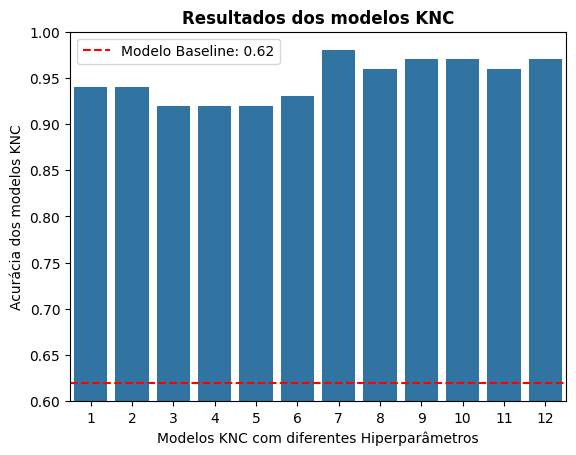

In [74]:
grafico_bar = sns.barplot(resultados_para_df, x = "HP", y = "acuracia")
grafico_bar.set_title("Resultados dos modelos KNC", fontweight = "bold")
grafico_bar.set_xlabel("Modelos KNC com diferentes Hiperparâmetros")
grafico_bar.set_ylabel("Acurácia dos modelos KNC")

grafico_bar.set_ylim(0.6, 1.0)
# Aqui definimos o limite inferior como 0.6

grafico_bar.axhline(y = acuracia_baseline, color = "red", linestyle = "--", label = f"Modelo Baseline: {acuracia_baseline}")
grafico_bar.legend()
# Esse trecho do grafico.axhline foi gerado com auxílio de AI

A partir do gráfico de barras, vemos claramenteque todos os modelos tiveram um desempenho muito superior ao do baseline (0.62), o que era esperado. Além disso, os modelos 1-6 (treinados com todos os atributos) tiveram um desempenho pior que os modelos 7-12 (treinados com o subset). Esse é um resultado interessante, pois intuitivamente os melhores modelos são aqueles treinados com mais atributos, mas o resultado mostrou justamente o contrário.

Vamos plotar outro gráfico a fim de comparar melhor as diferenças entre os hiperparâmetros. Esse gráfico será um catplot, pois ele é ideal para visualizar a relação entre diferentes variáveis. Nele temos 2 subgráficos que representam modelos treinados por todos os atributos e modelos treinados pelo subset. Em cada subgráfico, o eixo y representa a acurácia, enquanto x representa os valores de K. As métricas de distância estão evidenciadas pela cor das colunas:

##### Detalhe: O gráfico representa a acurácia dos modelos a partir de 0.9, o que permite uma comparação clara entre os modelos. Ele foi gerado com o auxílio do site Seaborn Pydata, na referência [5].

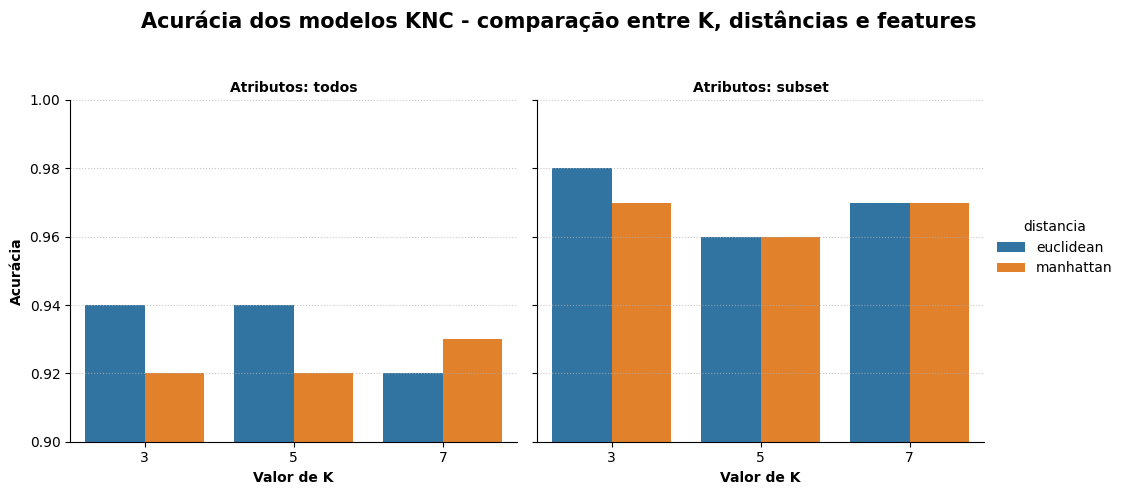

In [75]:
grafico_catplot = sns.catplot(data = resultados_para_df, x = "K", y = "acuracia", hue = "distancia", col = "atributos", kind = "bar")

grafico_catplot.set_axis_labels("Valor de K", "Acurácia", fontweight = "bold")
grafico_catplot.set_titles(col_template = "Atributos: {col_name}", fontweight = "bold")
grafico_catplot.fig.suptitle("Acurácia dos modelos KNC - comparação entre K, distâncias e features", fontsize = 15, fontweight = "bold")
grafico_catplot.fig.subplots_adjust(top = 0.8)
# O .fig.subplots_adjust posiciona o título mais para cima, evitando sobreposição de textos


# Define limites consistentes para o eixo Y em todos os subplots
for ax in grafico_catplot.axes.flat:
    ax.set_ylim(0.9, 1.0)
    ax.grid(axis = "y", linestyle = ":", alpha = 0.7)

print(grafico_catplot)

Pelo gráfico catplot, identificamos alguns padrões interessantes. A acurácia superior dos modelos treinados pelo subset está mais evidente. Além disso, modelos que utilizam a distância euclidiana tiveram, no geral, um desempenho melhor que os da distância manhattan (com apenas 1 exceção, identificada no 1º subgráfico no valor K = 7). Também podemos tirar conclusões sobre o valor de K: os melhores desempenhos foram com K = 3, superando os modelos treinados com K = 5 e com K = 7.
 Por fim, levando em conta tudo que foi discutido nesse gráfico, o modelo de maior acurácia (0.98) é justamente aquele que combina os parâmetros que, no geral, tiveram os melhores resultados: subset, distância euclidiana e K = 3. Os três modelos de menor acurácia (0.92) apresentam valores de K diferentes (3, 5 e 7), sendo 2 deles com a distância manhattan e 1 com a euclidiana; mas os três foram treinados com todos os atributos, e não pelo subset.

### Conclusões e principais aprendizados:

É muito interessante ver os resultados que podem ser atingidos puramente com estatística, análise de dados e programação. Nessa atividade, a criação e treinamento de modelos preditivos de CKD permite antecipar a doença e realizar diagnósticos mais precisos, o que é uma revolução para a medicina e quaisquer outras áreas que possam se beneficiar de predições.

Analisando os resultados dos modelos, o padrão que mais chama atenção é o desempenho dos modelos treinados pelo subset - 9 atributos selecionados a partir de dados científicos tiveram uma acurácia consistentemente maior do que a de modelos treinados com os 24 atributos. Intuitivamente, modelos treinados com mais atributos deveriam ser mais eficazes do que os treinados com menos atributos, mas os resultados são diferentes do esperado. Como podemos explicar esses resultados contra-intuitivos? Uma boa explicação é que o subset foi criado com a intenção de priorizar os atributos com uma relação à CKD cientificamente comprovada. Então, atributos menos relacionados com CKD foram desconsiderados, resultando numa acurácia mais precisa dos modelos treinados com o subset.

Além disso, observamos que modelos treinados com os parâmetros K = 3 e distância euclidiana obtiveram melhores resultados do que os outros modelos, embora não de forma tão consistente quanto o subset, já que houveram contraexemplos. Também não era esperado que a distância euclidiana tivesse desempenho melhor do que a manhattan, dado que a euclidiana é mais sensível a dados esparsos e muitos atributos (que é justamente o caso do dataset utilizado nesta atividade). Isso pode ser explicado pelo processo de imputação, que deixa os dados menos esparsos e gera ruídos (já que preenche dados faltantes com a média ou moda, no caso do método de imputação utilizado especificamente nesta atividade). Em relação aos valores de K, a alta dimensionalidade e esparsidade dos dados podem ter prejudicado os valores 5 e 7, além do ruído gerado pela imputação.

No fim, a melhor acurácia registrada foi 0.98 e a menor é 0.92, com média 0.948 para os 12 modelos KNC. Todas as acurácias foram muito superiores ao modelo baseline (todas passaram de 0.62 tranquilamente). Uma acurácia alta sugere que os modelos foram bem treinados, mas essa não é uma relação bem definida; uma junção de fatores desde a coleta dos dados até a etapa de treinamento é o que realmente contribui para a eficiência dos modelos.

### Aprendizados com essa atividade:

Aprender na prática o processo de tratamento de dados até a criação e treinamento de modelos preditivos é muito enriquecedor. Compreendi que existem várias ferramentas e técnicas diferentes para desenvolver modelos parecidos, mas essencialmente diferentes; compreender essas ferramentas é o que dá liberdade de explorar e testar diferentes modelos em diversas situações, geralmente com o objetivo de melhorar/otimizar resultados.
Pessoalmente, me vejo utilizando modelos preditivos no dia a dia, e cada linha de código me ajudou a compreender um pouco mais do mundo do Aprendizado de Máquina, de modo que posso aplicar meus conhecimentos depois.

### Descrição do uso de IA neste trabalho:

  A AI do ChatGPT foi utilizada para compreender a proposta da atividade e como ela se adequa à realidade, considerando que o Dataset selecionado para o projeto é real (não sintético). O processo de seleção do Dataset comparou atributos, relevância atual e engajamento pessoal com o Dataset, com o auxílio do ChatGPT. A criação dos hiperparâmetros, bem como erros ocasionais no código, foram tópicos de discussão com a AI.

Link da conversa com o ChatGPT: https://chatgpt.com/share/6aa73b7f-29e0-83e9-a9a9-54e168f6c880

### Referências:

[1] https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease

[2] https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html

[3] https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease

[4] https://pmc.ncbi.nlm.nih.gov/articles/PMC10950726/

[5] https://seaborn.pydata.org/generated/seaborn.catplot.html#seaborn.catplot